Epoch 0 |  Loss = 61.07109451293945
Epoch 500 |  Loss = 0.6978985071182251
Epoch 1000 |  Loss = 0.5943588614463806
Epoch 1500 |  Loss = 0.5420127511024475
Epoch 2000 |  Loss = 0.5005208849906921
Epoch 2500 |  Loss = 0.4766213595867157
Epoch 3000 |  Loss = 0.4304880201816559
Epoch 3500 |  Loss = 0.38899293541908264
Epoch 4000 |  Loss = 0.36115965247154236
Epoch 4500 |  Loss = 0.41040492057800293
Final Energy = 1.6896626949310303
**************************
Epoch 0 |  Loss = 1370.522705078125
Epoch 500 |  Loss = 1.0005512237548828
Epoch 1000 |  Loss = 0.6675431132316589
Epoch 1500 |  Loss = 0.629224419593811
Epoch 2000 |  Loss = 0.5949645638465881
Epoch 2500 |  Loss = 0.5631718635559082
Epoch 3000 |  Loss = 0.5320325493812561
Epoch 3500 |  Loss = 0.4988636374473572
Epoch 4000 |  Loss = 0.4613650143146515
Epoch 4500 |  Loss = 0.4216448664665222
Final Energy = 1.710108995437622
**************************
Epoch 0 |  Loss = 859.9053955078125
Epoch 500 |  Loss = 1.0270471572875977
Epoch 1000 |

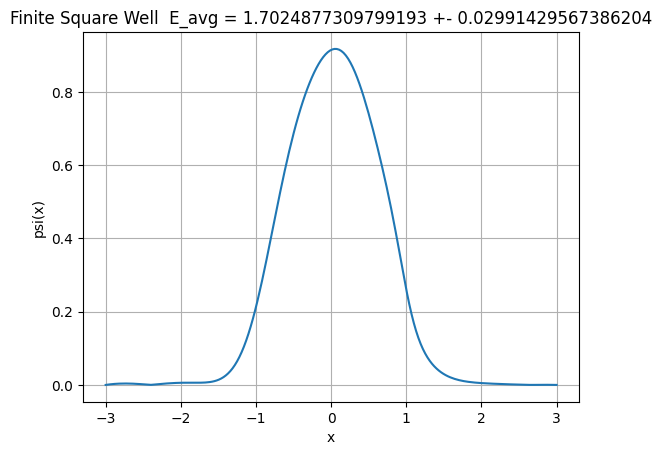

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 40)
        self.fc2 = nn.Linear(40, 40)
        self.fc3 = nn.Linear(40, 1)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x 

def potential(x):
    return torch.where(torch.abs(x) <= 1.0, torch.zeros_like(x), 20.0 * torch.ones_like(x))

def psi(model, x):
    return (x + 3.0) * (3.0 - x) * model(x)

x = torch.linspace(-3, 3, 200).reshape(-1, 1)
x.requires_grad_(True)
ES=[]

for n in range (5):
    model = Net()
    E = nn.Parameter(torch.tensor([1.0]))
    optimizer = torch.optim.Adam(list(model.parameters()) + [E], lr=1e-3)
    for epoch in range(5000):
        optimizer.zero_grad()
        psi_pred = psi(model, x)
        psi_x = torch.autograd.grad(psi_pred, x, grad_outputs=torch.ones_like(psi_pred), create_graph=True)[0]
        psi_xx = torch.autograd.grad(psi_x, x, grad_outputs=torch.ones_like(psi_x), create_graph=True)[0]

        V = potential(x)
        
        residual = -psi_xx + V * psi_pred - E * psi_pred
        pde_loss = torch.mean(residual ** 2)

        dx=6.0 / 199
        norm = torch.sum(psi_pred**2) *dx
        norm_loss = (norm - 1.0) ** 2

        loss = pde_loss + 10.0 * norm_loss

        loss.backward()
        optimizer.step()
        if epoch % 500 == 0:
            print(f"Epoch {epoch} |  Loss = {loss.item()}")
    with torch.no_grad():
        psi_nn = psi(model, x).numpy()
    x_np = x.detach().numpy()
    print("Final Energy =", E.item())
    print("**************************")
    ES.append(E.item())
ES=np.array(ES)
mean = np.mean(ES)
error=np.std(ES)
plt.plot(x_np, abs(psi_nn))
plt.xlabel("x")
plt.ylabel("psi(x)")
plt.title(f"Finite Square Well  E_avg = {mean} +- {error}")
plt.grid(True)
plt.show()

<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ATHARV\AppData\Local\Temp\ipykernel_23960\2945807259.py:43: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$\psi(x)$")


Epoch 0 | E = 6.000999927520752 | PDE = 1520.428955078125 | Norm = 46.26560974121094 | Orth = 0.2827746868133545
Epoch 500 | E = 6.117167949676514 | PDE = 28.62710189819336 | Norm = 0.8445853590965271 | Orth = 0.04762454330921173
Epoch 1000 | E = 6.28624153137207 | PDE = 25.3328914642334 | Norm = 0.8589272499084473 | Orth = 0.0370924174785614
Epoch 1500 | E = 6.484879970550537 | PDE = 20.533979415893555 | Norm = 0.8773356676101685 | Orth = 0.025197118520736694
Epoch 2000 | E = 6.672933101654053 | PDE = 15.67077922821045 | Norm = 0.8985918760299683 | Orth = 0.014306039549410343
Epoch 2500 | E = 6.8310227394104 | PDE = 12.587467193603516 | Norm = 0.919528603553772 | Orth = 0.006558462977409363
Epoch 3000 | E = 6.971467971801758 | PDE = 10.908543586730957 | Norm = 0.9336461424827576 | Orth = 0.002652733586728573
Epoch 3500 | E = 7.101718902587891 | PDE = 9.351228713989258 | Norm = 0.941699206829071 | Orth = 0.001162384171038866
Epoch 4000 | E = 7.209105014801025 | PDE = 7.672554969787598 

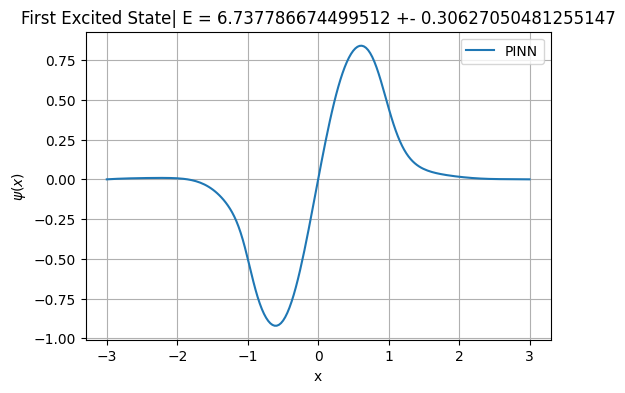

In [12]:
psi_ground = psi(model, x).detach()

def psi_excited(model, x):
    return x*(x + 3.0) * (3.0 - x) * model(x)

ES1=[]
for n in range(5):
    model1 = Net()
    E1 = nn.Parameter(torch.tensor([6.0]))
    optimizer = torch.optim.Adam(list(model1.parameters()) + [E1],lr=1e-3)

    for epoch in range(5000):
        optimizer.zero_grad()

        psi1 = psi_excited(model1, x)

        psi_x = torch.autograd.grad(psi1,x,grad_outputs=torch.ones_like(psi1),create_graph=True)[0]
        psi_xx =  torch.autograd.grad(psi_x,x,grad_outputs=torch.ones_like(psi_x),create_graph=True)[0]

        residual = -psi_xx + potential(x) * psi1 - E1 * psi1
        pde_loss = torch.mean(residual**2)
        norm = torch.sum(psi1**2) * dx
        norm_loss = (norm - 1.0)**2
        orth_loss = (torch.sum(psi_ground * psi1) * dx)**2
        loss = (pde_loss+ 100 * norm_loss+ 100 * orth_loss)
        loss.backward()
        optimizer.step()
        if epoch % 500 == 0:
            print(f"Epoch {epoch} | E = {E1.item()} | PDE = {pde_loss.item()} | Norm = {norm.item()} | Orth = {orth_loss.item()}")
       
        
    print("*********************************************************************")
    with torch.no_grad():
        psi1 = psi_excited(model1, x)
    ES1.append(E1.item())
    
ES1=np.array(ES1)
mean1=np.mean(ES1)
error1=np.std(ES1)
plt.figure(figsize=(6,4))
plt.plot(x.detach().numpy().squeeze(),psi1.detach().numpy().squeeze(),label='PINN')
plt.xlabel("x")
plt.ylabel("$\psi(x)$")
plt.title(f"First Excited State| E = {mean1} +- {error1}")
plt.grid(True)
plt.legend()
plt.show()

0 3.1114399433135986 1.0010000467300415
500 1.000093698501587 1.0183159112930298
1000 1.000013828277588 1.0186108350753784
1500 1.0000090599060059 1.0188606977462769
2000 1.0000097751617432 1.0191553831100464
2500 1.0000054836273193 1.0203241109848022
3000 1.0000059604644775 1.0227082967758179
3500 1.0000048875808716 1.028702735900879
4000 1.0002071857452393 1.0354684591293335
4500 1.0000993013381958 1.0362186431884766


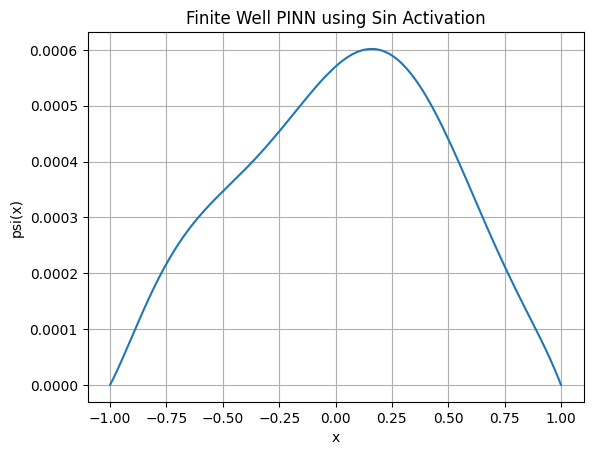

Energy = 1.0466697216033936


In [32]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 32) 
        self.layer2 = nn.Linear(32, 32)
        self.layer3 = nn.Linear(32, 1)
        self.E = nn.Parameter(torch.tensor([1.0]))

    def forward(self, x):
        hidden1 = self.layer1(x)
        activated1 = torch.sin(hidden1)
        hidden2 = self.layer2(activated1)
        activated2 = torch.sin(hidden2)
        nn_output = self.layer3(activated2)
        boundary_condition = 1 - x**2
        psi = boundary_condition * nn_output

        return psi


model = PINN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5000):

    x = torch.rand(300,1)*2 - 1
    x.requires_grad_(True)

    psi = model(x)

    dpsi = torch.autograd.grad(psi,x,grad_outputs=torch.ones_like(psi),create_graph=True)[0]

    ddpsi = torch.autograd.grad(dpsi,x,grad_outputs=torch.ones_like(dpsi),create_graph=True)[0]

    V = torch.where(torch.abs(x) < 0.5,torch.tensor(0.0),torch.tensor(20.0))

    residual = -ddpsi + V*psi - model.E*psi

    loss_pde = torch.mean(residual**2)

    norm = torch.mean(psi**2) * 2

    loss_norm = (norm - 1)**2

    loss = loss_pde + loss_norm

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(epoch, loss.item(), model.E.item())

x_plot = torch.linspace(-1,1,1000).reshape(-1,1)

with torch.no_grad():
    psi_plot = model(x_plot)

plt.plot(x_plot.numpy(), psi_plot.numpy())
plt.xlabel("x")
plt.ylabel("psi(x)")
plt.title("Finite Well PINN using Sin Activation")
plt.grid()
plt.show()

print("Energy =", model.E.item())

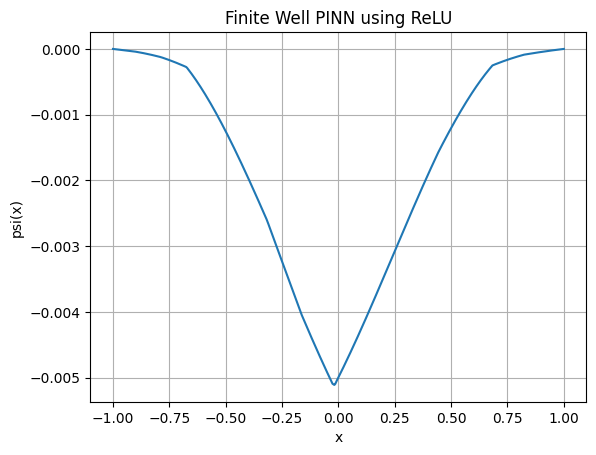

Energy = 1.0704588890075684


In [31]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )

        self.E = nn.Parameter(torch.tensor([1.0]))

    def forward(self,x):
        return (1-x**2)*self.net(x)

model = PINN()

optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

for epoch in range(3000):

    x = torch.rand(200,1)*2 - 1
    x.requires_grad_(True)

    psi = model(x)

    dpsi = torch.autograd.grad(
        psi,
        x,
        grad_outputs=torch.ones_like(psi),
        create_graph=True
    )[0]

    ddpsi = torch.autograd.grad(
        dpsi,
        x,
        grad_outputs=torch.ones_like(dpsi),
        create_graph=True
    )[0]

    V = torch.where(
        torch.abs(x) < 0.5,
        torch.tensor(0.0),
        torch.tensor(20.0)
    )

    residual = -ddpsi + V*psi - model.E*psi

    loss_pde = torch.mean(residual**2)

    loss_norm = (torch.mean(psi**2)*2 - 1)**2

    loss = loss_pde + loss_norm

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

x_plot = torch.linspace(-1,1,500).reshape(-1,1)

with torch.no_grad():
    psi_plot = model(x_plot)

plt.plot(x_plot.numpy(),psi_plot.numpy())
plt.xlabel("x")
plt.ylabel("psi(x)")
plt.title("Finite Well PINN using ReLU")
plt.grid()
plt.show()

print("Energy =",model.E.item())